In [1]:
import os
import pickle
import pandas as pd
    
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# directory of CSV files
shap_directory = "../_datasets/Satimage/shap"

scoringResults_directory = ""

sorted_orderScore = pd.DataFrame()

In [3]:
sorted_orderScore = []

In [4]:
sorted_orderScore = pd.read_csv(scoringResults_directory+"shap_orderScore.csv")

In [5]:
sorted_orderScore.drop("Unnamed: 0",axis=1,inplace = True)

In [6]:
sorted_orderScore

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,shap_list_ir_1,shap_list_ir_1_subset_100,orderMean,"['C15attr', 'F18attr', 'Aattr', 'E17attr', 'C3..."
1,shap_list_ir_1,shap_list_ir_1_subset_100,orderStd,"['C15attr', 'F18attr', 'E17attr', 'Aattr', 'E2..."
2,shap_list_ir_1,shap_list_ir_1_subset_100,orderSum,"['C15attr', 'F18attr', 'Aattr', 'E17attr', 'C3..."
3,shap_list_ir_1,shap_list_ir_1_subset_101,orderMean,"['C27attr', 'C15attr', 'E23attr', 'E17attr', '..."
4,shap_list_ir_1,shap_list_ir_1_subset_101,orderStd,"['C27attr', 'C15attr', 'E23attr', 'B14attr', '..."
...,...,...,...,...
1525,shap_list_ir_5,shap_list_ir_5_subset_99,orderStd,"['C15attr', 'E11attr', 'F18attr', 'E17attr', '..."
1526,shap_list_ir_5,shap_list_ir_5_subset_99,orderSum,"['E11attr', 'C15attr', 'C27attr', 'F18attr', '..."
1527,shap_list_ir_5,shap_list_ir_5_subset_9,orderMean,"['E11attr', 'C15attr', 'Aattr', 'B14attr', 'F1..."
1528,shap_list_ir_5,shap_list_ir_5_subset_9,orderStd,"['C15attr', 'F12attr', 'B14attr', 'E11attr', '..."


In [7]:
sorted_orderScore["Sorted_Features"][0]

"['C15attr', 'F18attr', 'Aattr', 'E17attr', 'C3attr', 'B14attr', 'C27attr', 'E11attr', 'C21attr', 'B26attr', 'E29attr', 'D16attr', 'E23attr', 'D10attr', 'A13attr', 'A7attr', 'B2attr', 'F30attr', 'A25attr', 'Dattr', 'B8attr', 'Cattr', 'Eattr', 'E5attr', 'D22attr', 'D4attr', 'C9attr', 'F6attr', 'F12attr', 'F24attr', 'D28attr', 'Fattr', 'A19attr', 'A1attr', 'B20attr', 'Battr']"

## Max density values

SHAP value for max KDE (for each feature) - to change, right now its max bar from histogram, a bit generalized maxShap 

In [8]:
maxDensityValues = pd.read_csv(scoringResults_directory+"shap_maxDensityValues.csv")
maxDensityValues.drop("Unnamed: 0",axis=1,inplace = True)

In [9]:
maxDensityValues[:10]

,imbalanceRatio,Subset,feature,Indicator,freq1,freq2,freq3
0,shap_list_ir_1,shap_list_ir_1_subset_100,Aattr,localMax_Aattr,0.048470,0.036975,-0.020500
1,shap_list_ir_1,shap_list_ir_1_subset_100,Battr,localMax_Battr,0.001001,0.002482,-0.000479
2,shap_list_ir_1,shap_list_ir_1_subset_100,Cattr,localMax_Cattr,-0.002082,0.002086,0.022925
3,shap_list_ir_1,shap_list_ir_1_subset_100,Dattr,localMax_Dattr,0.007497,0.011041,-0.003137
4,shap_list_ir_1,shap_list_ir_1_subset_100,Eattr,localMax_Eattr,0.009124,0.004647,0.011362
5,shap_list_ir_1,shap_list_ir_1_subset_100,Fattr,localMax_Fattr,0.001424,-0.001321,0.009659
6,shap_list_ir_1,shap_list_ir_1_subset_100,A1attr,localMax_A1attr,0.002661,0.004130,0.001192
7,shap_list_ir_1,shap_list_ir_1_subset_100,B2attr,localMax_B2attr,0.013795,-0.003347,0.000939
8,shap_list_ir_1,shap_list_ir_1_subset_100,C3attr,localMax_C3attr,0.027332,0.034455,-0.015406
9,shap_list_ir_1,shap_list_ir_1_subset_100,D4attr,localMax_D4attr,0.006312,0.003395,0.009228


In [10]:
maxDensityValues.columns

Index(['imbalanceRatio', 'Subset', 'feature', 'Indicator', 'freq1', 'freq2',
       'freq3'],
      dtype='object')

In [11]:
maxDensityValues[['imbalanceRatio', 'feature', 'freq1']]

,imbalanceRatio,feature,freq1
0,shap_list_ir_1,Aattr,0.048470
1,shap_list_ir_1,Battr,0.001001
2,shap_list_ir_1,Cattr,-0.002082
3,shap_list_ir_1,Dattr,0.007497
4,shap_list_ir_1,Eattr,0.009124
...,...,...,...
18355,shap_list_ir_5,B26attr,0.016266
18356,shap_list_ir_5,C27attr,0.015222
18357,shap_list_ir_5,D28attr,0.002649
18358,shap_list_ir_5,E29attr,0.007078


In [12]:
# Group by 'imbalanceRatio' and compute statistics for 'freq1'
freq1Statistics = (
    maxDensityValues.groupby(["imbalanceRatio", 'feature'])
    .agg(
        median=("freq1", "median"),
        mean=("freq1", "mean"),
        std=("freq1", "std"),
        iqr=("freq1", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)

In [13]:
freq1Statistics.reset_index(inplace=True)

In [14]:
df_melted = freq1Statistics.melt(id_vars=["imbalanceRatio"], var_name="Statistic", value_name="Value")

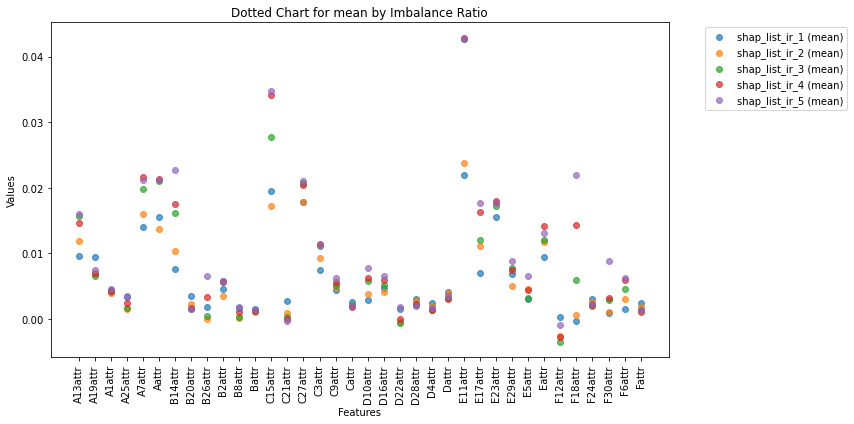

In [15]:
# Reset index to prepare for plotting
df_reset = freq1Statistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalanceRatio"].unique():
    subset = df_reset[df_reset["imbalanceRatio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)  # median chart
    plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)  # mean chart
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)  # std chart
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)  # iqr chart

plt.xticks(rotation=90)
plt.title("Dotted Chart for mean by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

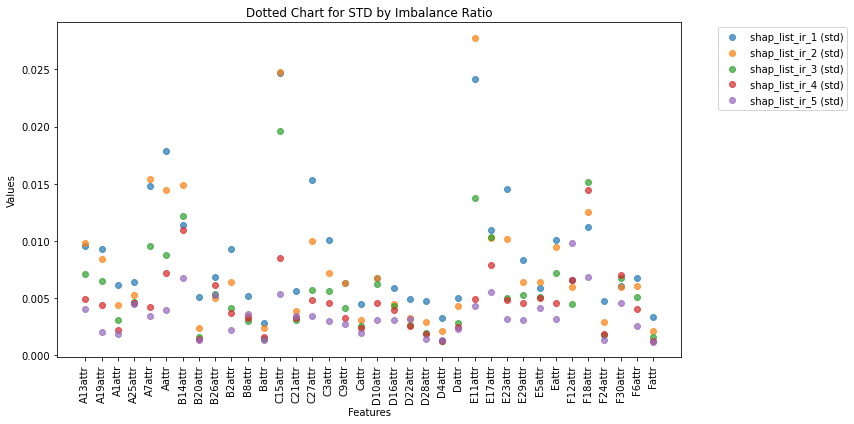

In [16]:
# Reset index to prepare for plotting
df_reset = freq1Statistics.reset_index()

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalanceRatio"].unique():
    subset = df_reset[df_reset["imbalanceRatio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

IR1 - 2%
IR2 - 5%
IR5 - 20%

-- STD results are proportional/similar to IQR
-- Lower Imbalance ratio, the model provides better consistency regarding XAI results. STD is 2x lower than for IR 1
    -- it is true especially for the most important features, these one have the most differences between the IR
    
-- If the mean is similar between IR, and std is different. It means that model is aiming at the same values, hovewer is getting more confused/mistaken with growing IR 

***
***
***
## Mean SHAP

In [17]:
sorted_orderValuesScore = []
sorted_orderValuesScore = pd.read_csv(scoringResults_directory+"sorted_orderValuesScore.csv")
sorted_orderValuesScore.drop("Unnamed: 0",axis=1,inplace = True)
sorted_orderValuesScore.columns = ['feature', 'shapMean', 'shapStd', 'shapSum', 'subset', 'imbalance_ratio']

In [18]:
sorted_orderValuesScore

,feature,shapMean,shapStd,shapSum,subset,imbalance_ratio
0,Aattr,0.039124,0.025960,97.810913,shap_list_ir_1_subset_100,shap_list_ir_1
1,Battr,0.002535,0.002730,6.336445,shap_list_ir_1_subset_100,shap_list_ir_1
2,Cattr,0.007762,0.008896,19.404435,shap_list_ir_1_subset_100,shap_list_ir_1
3,Dattr,0.008915,0.005884,22.288523,shap_list_ir_1_subset_100,shap_list_ir_1
4,Eattr,0.007753,0.005292,19.382674,shap_list_ir_1_subset_100,shap_list_ir_1
...,...,...,...,...,...,...
18355,B26attr,0.022827,0.021556,57.067076,shap_list_ir_5_subset_9,shap_list_ir_5
18356,C27attr,0.021175,0.009884,52.938087,shap_list_ir_5_subset_9,shap_list_ir_5
18357,D28attr,0.002737,0.002114,6.842421,shap_list_ir_5_subset_9,shap_list_ir_5
18358,E29attr,0.009033,0.005669,22.582149,shap_list_ir_5_subset_9,shap_list_ir_5


In [19]:
# Group by 'imbalanceRatio' and compute statistics for 'shapMean'
meanStatistics = (
    sorted_orderValuesScore.groupby(["imbalance_ratio", 'feature'])
    .agg(
        median=("shapMean", "median"),
        mean=("shapMean", "mean"),
        std=("shapMean", "std"),
        iqr=("shapMean", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)
meanStatistics.reset_index(inplace=True)

In [20]:
meanStatistics[:5]

,imbalance_ratio,feature,median,mean,std,iqr
0,shap_list_ir_1,A13attr,0.015585,0.017069,0.009161,0.014041
1,shap_list_ir_1,A19attr,0.012558,0.013007,0.007081,0.008780
2,shap_list_ir_1,A1attr,0.009051,0.010679,0.007615,0.008014
3,shap_list_ir_1,A25attr,0.011164,0.012382,0.006434,0.007040
4,shap_list_ir_1,A7attr,0.019850,0.021473,0.009401,0.011537


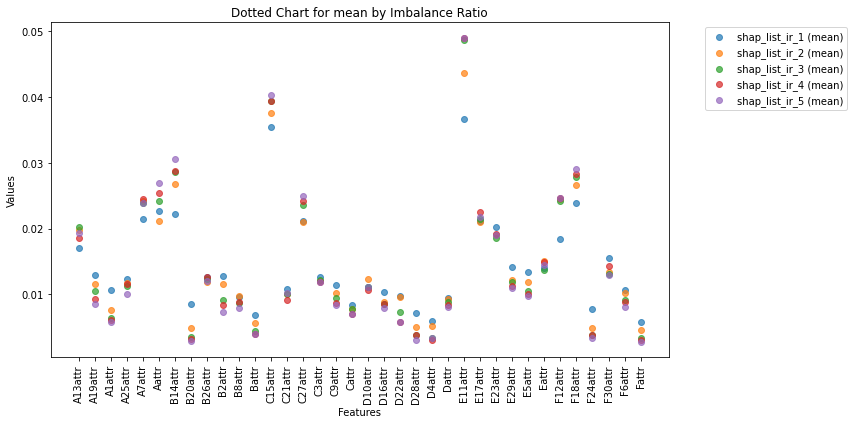

In [21]:
# Reset index to prepare for plotting
df_reset = meanStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)  # median chart
    plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)  # mean chart
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)  # std chart
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)  # iqr chart

plt.xticks(rotation=90)
plt.title("Dotted Chart for mean by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

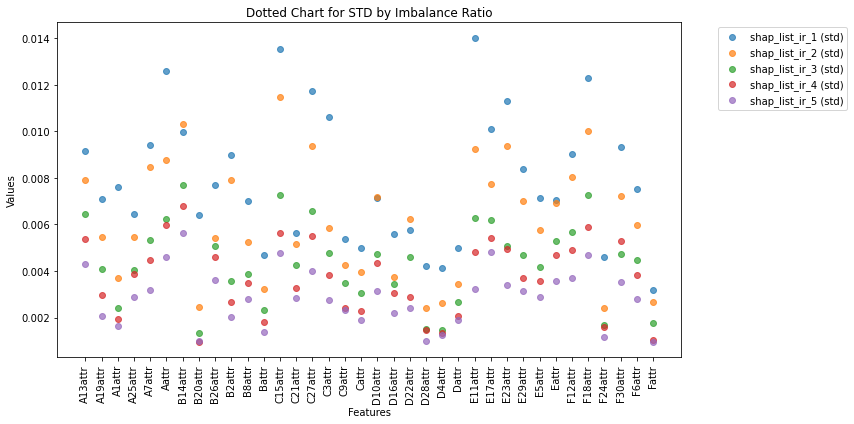

In [22]:
# Reset index to prepare for plotting
df_reset = meanStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

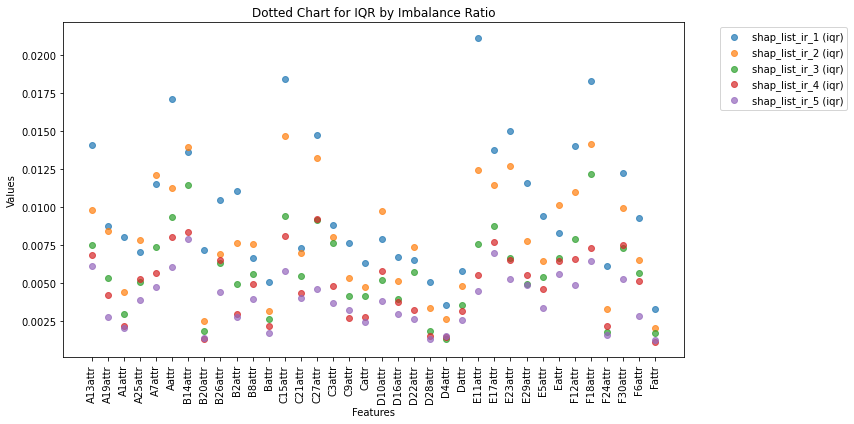

In [23]:
# Reset index to prepare for plotting
df_reset = meanStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
    plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for IQR by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

***
***
***
## std SHAP

- Variability of std for Shap (level I Shap, for subsets)
- Not only standard deviation increasing with increasing Imbalance Ration, but also Shap std is more changing for highier imbalance. It meas that there is more outlier results for highier IR

In [24]:
# Group by 'imbalanceRatio' and compute statistics for 'shapMean'
stdStatistics = (
    sorted_orderValuesScore.groupby(["imbalance_ratio", 'feature'])
    .agg(
        median=("shapStd", "median"),
        mean=("shapStd", "mean"),
        std=("shapStd", "std"),
        iqr=("shapStd", lambda x: x.quantile(0.75) - x.quantile(0.25)),
    )
)
stdStatistics.reset_index(inplace=True)

In [25]:
stdStatistics

,imbalance_ratio,feature,median,mean,std,iqr
0,shap_list_ir_1,A13attr,0.012293,0.013772,0.007772,0.009844
1,shap_list_ir_1,A19attr,0.008336,0.009030,0.004918,0.005985
2,shap_list_ir_1,A1attr,0.007907,0.010129,0.008001,0.008742
3,shap_list_ir_1,A25attr,0.009999,0.011677,0.006917,0.007339
4,shap_list_ir_1,A7attr,0.012942,0.013743,0.006223,0.008318
...,...,...,...,...,...,...
175,shap_list_ir_5,F18attr,0.022510,0.022467,0.003830,0.005046
176,shap_list_ir_5,F24attr,0.002505,0.002619,0.000929,0.001326
177,shap_list_ir_5,F30attr,0.010487,0.010880,0.003135,0.004816
178,shap_list_ir_5,F6attr,0.005612,0.005949,0.002282,0.002277


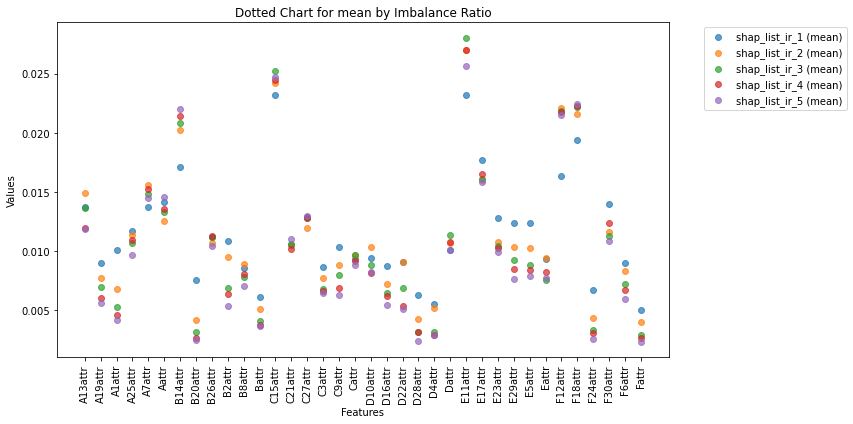

In [26]:
# Reset index to prepare for plotting
df_reset = stdStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)  # median chart
    plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)  # mean chart
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)  # std chart
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)  # iqr chart

plt.xticks(rotation=90)
plt.title("Dotted Chart for mean by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

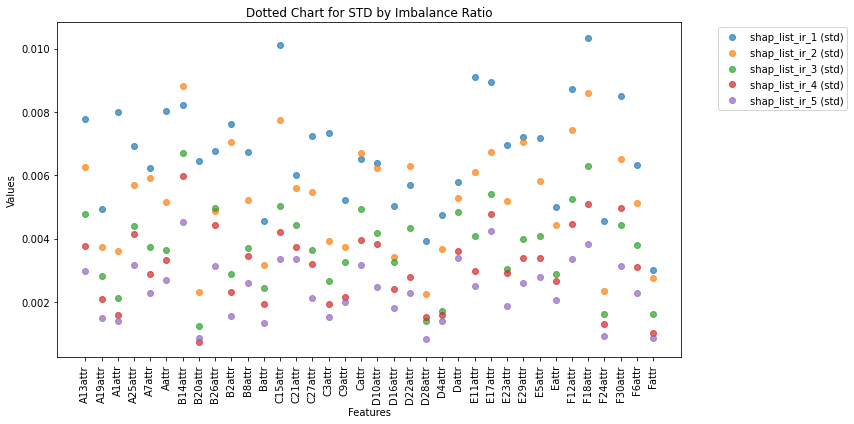

In [27]:
# Reset index to prepare for plotting
df_reset = stdStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
    plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for STD by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

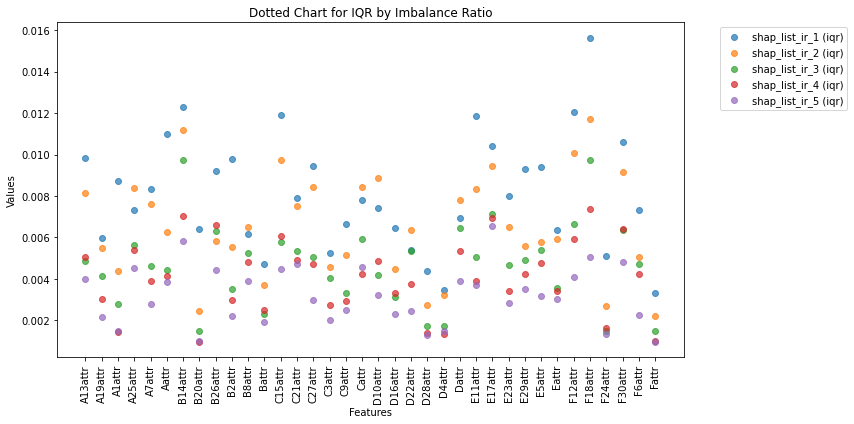

In [28]:
# Reset index to prepare for plotting
df_reset = stdStatistics

# Plotting the dotted chart
plt.figure(figsize=(12, 6))
for ir in df_reset["imbalance_ratio"].unique():
    subset = df_reset[df_reset["imbalance_ratio"] == ir]
#     plt.scatter(subset["feature"], subset["median"], label=f"{ir} (median)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["mean"], label=f"{ir} (mean)", alpha=0.7)
#     plt.scatter(subset["feature"], subset["std"], label=f"{ir} (std)", alpha=0.7)
    plt.scatter(subset["feature"], subset["iqr"], label=f"{ir} (iqr)", alpha=0.7)

plt.xticks(rotation=90)
plt.title("Dotted Chart for IQR by Imbalance Ratio")
plt.ylabel("Values")
plt.xlabel("Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

***
***
***
## Features ranking based on position/order/significance

In [29]:
sorted_orderScore[:3]

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,shap_list_ir_1,shap_list_ir_1_subset_100,orderMean,"['C15attr', 'F18attr', 'Aattr', 'E17attr', 'C3..."
1,shap_list_ir_1,shap_list_ir_1_subset_100,orderStd,"['C15attr', 'F18attr', 'E17attr', 'Aattr', 'E2..."
2,shap_list_ir_1,shap_list_ir_1_subset_100,orderSum,"['C15attr', 'F18attr', 'Aattr', 'E17attr', 'C3..."


In [30]:
sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Indicator', 'Sorted_Features']]

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,shap_list_ir_1,shap_list_ir_1_subset_100,orderMean,"['C15attr', 'F18attr', 'Aattr', 'E17attr', 'C3..."
3,shap_list_ir_1,shap_list_ir_1_subset_101,orderMean,"['C27attr', 'C15attr', 'E23attr', 'E17attr', '..."
6,shap_list_ir_1,shap_list_ir_1_subset_102,orderMean,"['E11attr', 'E29attr', 'F30attr', 'A13attr', '..."
9,shap_list_ir_1,shap_list_ir_1_subset_10,orderMean,"['E11attr', 'Aattr', 'F12attr', 'B14attr', 'A7..."
12,shap_list_ir_1,shap_list_ir_1_subset_11,orderMean,"['C27attr', 'E11attr', 'B14attr', 'E23attr', '..."
...,...,...,...,...
1515,shap_list_ir_5,shap_list_ir_5_subset_96,orderMean,"['E11attr', 'C15attr', 'B14attr', 'C27attr', '..."
1518,shap_list_ir_5,shap_list_ir_5_subset_97,orderMean,"['E11attr', 'C27attr', 'C15attr', 'B14attr', '..."
1521,shap_list_ir_5,shap_list_ir_5_subset_98,orderMean,"['E11attr', 'C15attr', 'E17attr', 'F18attr', '..."
1524,shap_list_ir_5,shap_list_ir_5_subset_99,orderMean,"['E11attr', 'C15attr', 'C27attr', 'F18attr', '..."


In [31]:
import pandas as pd

def extract_top_features(dataframe, column_name, top_features_amount):
    """
    Extract the top X features from the specified column in the DataFrame and add them as a new column.

    Parameters:
        dataframe (pd.DataFrame): Input DataFrame.
        column_name (str): Name of the column containing feature lists as strings.
        top_features_amount (int): Number of top features to extract.

    Returns:
        pd.DataFrame: DataFrame with an additional column containing the top X features as lists.
    """
    dataframe[f'top_{top_features_amount}_features'] = dataframe[column_name].apply(
        lambda x: eval(x)[:top_features_amount]
    )
    return dataframe





In [32]:
# use of extract_top_features 
df = sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Indicator', 'Sorted_Features']].copy()

# Define the number of top features to extract
top_features_amount = 5

# Apply the function to extract top features
orderIndicator = extract_top_features(df, "Sorted_Features", top_features_amount)

In [33]:
def calculate_unique_feature_lists_per_group(dataframe, group_column, list_column):
    """
    Calculate unique lists in the specified column of the DataFrame for each group.

    Parameters:
        dataframe (pd.DataFrame): Input DataFrame.
        group_column (str): Name of the column to group by.
        list_column (str): Name of the column containing feature lists as strings or lists.

    Returns:
        pd.DataFrame: DataFrame with columns for group values and unique feature lists.
    """
    unique_lists_per_group = []

    # Group by the specified column
    for group, group_df in dataframe.groupby(group_column):
        # Convert each list in the column to a tuple (to account for order sensitivity) and collect unique tuples
        unique_lists = set(tuple(row) for row in group_df[list_column].apply(lambda x: eval(x) if isinstance(x, str) else x))
        for unique_list in unique_lists:
            unique_lists_per_group.append({group_column: group, "unique_feature_list": unique_list})

    return pd.DataFrame(unique_lists_per_group)

In [34]:
orderIndicator

,imbalanceRatio,Subset,Indicator,Sorted_Features,top_5_features
0,shap_list_ir_1,shap_list_ir_1_subset_100,orderMean,"['C15attr', 'F18attr', 'Aattr', 'E17attr', 'C3...","[C15attr, F18attr, Aattr, E17attr, C3attr]"
3,shap_list_ir_1,shap_list_ir_1_subset_101,orderMean,"['C27attr', 'C15attr', 'E23attr', 'E17attr', '...","[C27attr, C15attr, E23attr, E17attr, Aattr]"
6,shap_list_ir_1,shap_list_ir_1_subset_102,orderMean,"['E11attr', 'E29attr', 'F30attr', 'A13attr', '...","[E11attr, E29attr, F30attr, A13attr, F12attr]"
9,shap_list_ir_1,shap_list_ir_1_subset_10,orderMean,"['E11attr', 'Aattr', 'F12attr', 'B14attr', 'A7...","[E11attr, Aattr, F12attr, B14attr, A7attr]"
12,shap_list_ir_1,shap_list_ir_1_subset_11,orderMean,"['C27attr', 'E11attr', 'B14attr', 'E23attr', '...","[C27attr, E11attr, B14attr, E23attr, A19attr]"
...,...,...,...,...,...
1515,shap_list_ir_5,shap_list_ir_5_subset_96,orderMean,"['E11attr', 'C15attr', 'B14attr', 'C27attr', '...","[E11attr, C15attr, B14attr, C27attr, F18attr]"
1518,shap_list_ir_5,shap_list_ir_5_subset_97,orderMean,"['E11attr', 'C27attr', 'C15attr', 'B14attr', '...","[E11attr, C27attr, C15attr, B14attr, E23attr]"
1521,shap_list_ir_5,shap_list_ir_5_subset_98,orderMean,"['E11attr', 'C15attr', 'E17attr', 'F18attr', '...","[E11attr, C15attr, E17attr, F18attr, A7attr]"
1524,shap_list_ir_5,shap_list_ir_5_subset_99,orderMean,"['E11attr', 'C15attr', 'C27attr', 'F18attr', '...","[E11attr, C15attr, C27attr, F18attr, E17attr]"


In [35]:
df = orderIndicator.copy()

# Calculate unique feature lists for each imbalanceRatio
unique_feature_lists_df = calculate_unique_feature_lists_per_group(df, "imbalanceRatio", "top_5_features")

In [36]:
unique_feature_lists_df

,imbalanceRatio,unique_feature_list
0,shap_list_ir_1,"(B14attr, E17attr, E11attr, C3attr, F18attr)"
1,shap_list_ir_1,"(E11attr, A13attr, B14attr, C3attr, F6attr)"
2,shap_list_ir_1,"(A1attr, C15attr, B2attr, E11attr, F30attr)"
3,shap_list_ir_1,"(A1attr, C15attr, Aattr, F12attr, C3attr)"
4,shap_list_ir_1,"(C15attr, E11attr, A13attr, Aattr, A1attr)"
...,...,...
459,shap_list_ir_5,"(C15attr, E11attr, B14attr, F18attr, C27attr)"
460,shap_list_ir_5,"(E11attr, C15attr, Aattr, E17attr, F18attr)"
461,shap_list_ir_5,"(E11attr, F18attr, C15attr, B14attr, Aattr)"
462,shap_list_ir_5,"(E11attr, F18attr, B14attr, F12attr, A7attr)"


In [37]:
def add_presence_columns(unique_feature_lists_df, dataframe, group_column, list_column):
    """
    Add new columns to the unique_feature_lists_df for each unique value in the group column.
    Each column indicates the presence (1) or absence (0) of the unique feature list in the original DataFrame's groups.

    Parameters:
        unique_feature_lists_df (pd.DataFrame): DataFrame with unique feature lists.
        dataframe (pd.DataFrame): Original DataFrame.
        group_column (str): Name of the column to group by.
        list_column (str): Name of the column containing feature lists as strings or lists.

    Returns:
        pd.DataFrame: Updated unique_feature_lists_df with new columns.
    """
    group_values = dataframe[group_column].unique()

    for group in group_values:
        group_features = set(
            tuple(row) for row in dataframe[dataframe[group_column] == group][list_column].apply(lambda x: eval(x) if isinstance(x, str) else x)
        )

        unique_feature_lists_df[group] = unique_feature_lists_df["unique_feature_list"].apply(
            lambda x: 1 if x in group_features else 0
        )

    return unique_feature_lists_df

In [38]:
unique_feature_lists_df

,imbalanceRatio,unique_feature_list
0,shap_list_ir_1,"(B14attr, E17attr, E11attr, C3attr, F18attr)"
1,shap_list_ir_1,"(E11attr, A13attr, B14attr, C3attr, F6attr)"
2,shap_list_ir_1,"(A1attr, C15attr, B2attr, E11attr, F30attr)"
3,shap_list_ir_1,"(A1attr, C15attr, Aattr, F12attr, C3attr)"
4,shap_list_ir_1,"(C15attr, E11attr, A13attr, Aattr, A1attr)"
...,...,...
459,shap_list_ir_5,"(C15attr, E11attr, B14attr, F18attr, C27attr)"
460,shap_list_ir_5,"(E11attr, C15attr, Aattr, E17attr, F18attr)"
461,shap_list_ir_5,"(E11attr, F18attr, C15attr, B14attr, Aattr)"
462,shap_list_ir_5,"(E11attr, F18attr, B14attr, F12attr, A7attr)"


In [39]:
unique_feature_lists_df = add_presence_columns(unique_feature_lists_df, unique_feature_lists_df, "imbalanceRatio", "unique_feature_list")

In [40]:
imbalanceRatio_columns = list(unique_feature_lists_df['imbalanceRatio'].unique())

In [41]:
imbalanceRatio_columns

['shap_list_ir_1',
 'shap_list_ir_2',
 'shap_list_ir_3',
 'shap_list_ir_4',
 'shap_list_ir_5']

In [42]:
def add_sum_column(unique_feature_lists_df, imbalanceRatio_columns):
    """
    Add a new column 'sum' to the DataFrame which sums values across specified imbalanceRatio columns.

    Parameters:
        unique_feature_lists_df (pd.DataFrame): DataFrame with unique feature lists and imbalanceRatio columns.
        imbalanceRatio_columns (list): List of column names to sum across.

    Returns:
        pd.DataFrame: Updated unique_feature_lists_df with the 'sum' column.
    """
    unique_feature_lists_df['sum'] = unique_feature_lists_df[imbalanceRatio_columns].sum(axis=1)
    return unique_feature_lists_df

In [43]:
unique_feature_lists_df = add_sum_column(unique_feature_lists_df, imbalanceRatio_columns)

In [44]:
unique_feature_lists_df

,imbalanceRatio,unique_feature_list,shap_list_ir_1,shap_list_ir_2,shap_list_ir_3,shap_list_ir_4,shap_list_ir_5,sum
0,shap_list_ir_1,"(B14attr, E17attr, E11attr, C3attr, F18attr)",1,0,0,0,0,1
1,shap_list_ir_1,"(E11attr, A13attr, B14attr, C3attr, F6attr)",1,0,0,0,0,1
2,shap_list_ir_1,"(A1attr, C15attr, B2attr, E11attr, F30attr)",1,0,0,0,0,1
3,shap_list_ir_1,"(A1attr, C15attr, Aattr, F12attr, C3attr)",1,0,0,0,0,1
4,shap_list_ir_1,"(C15attr, E11attr, A13attr, Aattr, A1attr)",1,0,0,0,0,1
...,...,...,...,...,...,...,...,...
459,shap_list_ir_5,"(C15attr, E11attr, B14attr, F18attr, C27attr)",0,0,0,0,1,1
460,shap_list_ir_5,"(E11attr, C15attr, Aattr, E17attr, F18attr)",0,0,0,0,1,1
461,shap_list_ir_5,"(E11attr, F18attr, C15attr, B14attr, Aattr)",0,0,0,0,1,1
462,shap_list_ir_5,"(E11attr, F18attr, B14attr, F12attr, A7attr)",0,0,0,0,1,1


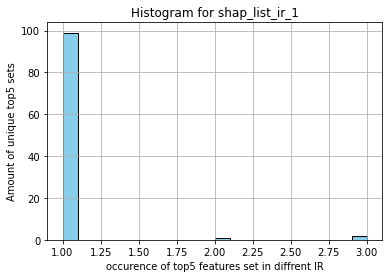

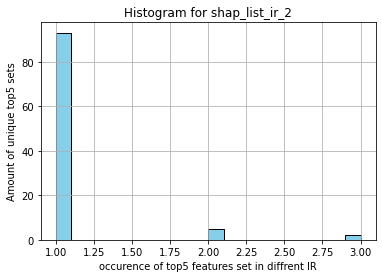

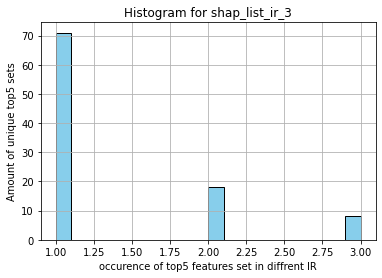

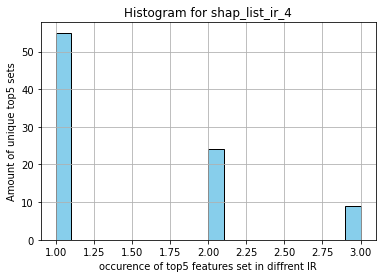

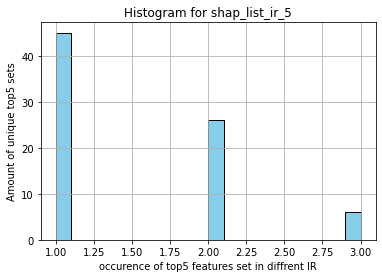

Wall time: 1.34 s


In [49]:
%%time

# Create histograms for each IR, to evaluate how many unique sets of the most important features was made
for ir_name in imbalanceRatio_columns:
    plt.figure(figsize=(6, 4))  # Set figure size
    plt.hist(unique_feature_lists_df[unique_feature_lists_df['imbalanceRatio']==ir_name]['sum'], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram for {ir_name}')
    plt.xlabel('occurence of top5 features set in diffrent IR')
    plt.ylabel('Amount of unique top5 sets')
    plt.grid(True)
    plt.show()

    
    # Save the histogram as a PNG file in the specified folder
#     filename = os.path.join(output_folder, f"Histogram_for_{feature.replace(' ', '_')}.png")  # Replace spaces with underscores for filenames
#     plt.savefig(filename, dpi=300, bbox_inches='tight')

- Results shows that growing imbalance IR5 => IR1 is shown in different sets of the most significant features.
    - For IR1 models have 40 new, unique sets of the most important features;
    - for IR3 (and less) there is no unique sets for that imbalance ratio 
- there is a trend of less amount of different sets of the most important features, only 8 for IR5, and 

In [46]:
unique_feature_lists_df['index'] = 1

In [47]:
unique_feature_lists_df22 = calculate_unique_feature_lists_per_group(unique_feature_lists_df, 'index', "unique_feature_list")

In [48]:
unique_feature_lists_df22

,index,unique_feature_list
0,1,"(E11attr, B14attr, Aattr, C15attr, E17attr)"
1,1,"(Aattr, F18attr, E11attr, F30attr, A7attr)"
2,1,"(E11attr, F18attr, Aattr, B14attr, A7attr)"
3,1,"(A1attr, C15attr, B2attr, E11attr, F30attr)"
4,1,"(E11attr, C15attr, Aattr, C27attr, E17attr)"
...,...,...
404,1,"(C15attr, E23attr, C27attr, A25attr, B14attr)"
405,1,"(E11attr, C15attr, C27attr, F18attr, A7attr)"
406,1,"(E11attr, F18attr, B14attr, F12attr, A7attr)"
407,1,"(F18attr, C15attr, C27attr, Aattr, F30attr)"


***
***
***
## Rand index
features order analysis (top 5 OR top 20% {for features_amount > 25}) according to mean SHAP

In [81]:
sorted_orderScore[sorted_orderScore['Indicator']=='orderMean'][['imbalanceRatio', 'Subset', 'Sorted_Features']]

,imbalanceRatio,Subset,Sorted_Features
0,shap_list_ir_1,shap_list_ir_1_subset_1000,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
3,shap_list_ir_1,shap_list_ir_1_subset_100,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
6,shap_list_ir_1,shap_list_ir_1_subset_101,"['AGE', 'HYPERTENSION', 'DIABETES', 'SEX_FEMAL..."
9,shap_list_ir_1,shap_list_ir_1_subset_102,"['AGE', 'HYPERTENSION', 'DIABETES', 'ARTHROSIS..."
12,shap_list_ir_1,shap_list_ir_1_subset_103,"['AGE', 'HYPERTENSION', 'DIABETES', 'DEMENTIA'..."
...,...,...,...
14985,shap_list_ir_5,shap_list_ir_5_subset_997,"['AGE', 'HYPERTENSION', 'DIABETES', 'HEART_FAI..."
14988,shap_list_ir_5,shap_list_ir_5_subset_998,"['AGE', 'HYPERTENSION', 'DIABETES', 'HEART_FAI..."
14991,shap_list_ir_5,shap_list_ir_5_subset_999,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
14994,shap_list_ir_5,shap_list_ir_5_subset_99,"['AGE', 'HYPERTENSION', 'DIABETES', 'DEMENTIA'..."


In [82]:
%%time
import pandas as pd
from sklearn.metrics.cluster import adjusted_rand_score


data = sorted_orderScore

# Initialize a dictionary to store results
results = []

# Iterate through each unique imbalanceRatio
for imbalance_ratio in data['imbalanceRatio'].unique():
    # Filter the DataFrame for the current imbalanceRatio
    subset_data = data[data['imbalanceRatio'] == imbalance_ratio]

    for _, row in subset_data.iterrows():
        # Extract the first 5 features from the Sorted_Features column
        sorted_features = eval(row['Sorted_Features'])  # Convert string representation of list to actual list
        top_5_features = sorted_features[:5]

        # Calculate Rand index (example calculation, modify as per actual use case)
        # Here, we're using random example data. Replace with your actual logic if needed.
        # Assume we compare top_5_features with a reference set of features
        reference_features = ['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_KIDNEY_DISEASE', 'HEART_FAILURE']
        rand_index = adjusted_rand_score(top_5_features, reference_features)

        # Append results
        results.append({
            'imbalanceRatio': imbalance_ratio,
            'Subset': row['Subset'],
            'RandIndex': rand_index,
            'Top5Features': top_5_features
        })

# Create a results DataFrame
results_df = pd.DataFrame(results)

# Save the results to a new CSV file
# results_df.to_csv("rand_index_results.csv", index=False)

# print("Rand index calculation completed. Results saved to 'rand_index_results.csv'.")


Wall time: 18.3 s


In [83]:
results_df

,imbalanceRatio,Subset,RandIndex,Top5Features
0,shap_list_ir_1,shap_list_ir_1_subset_1000,1.0,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D..."
1,shap_list_ir_1,shap_list_ir_1_subset_1000,1.0,"[AGE, DIABETES, HYPERTENSION, CHRONIC_KIDNEY_D..."
2,shap_list_ir_1,shap_list_ir_1_subset_1000,1.0,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D..."
3,shap_list_ir_1,shap_list_ir_1_subset_100,1.0,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D..."
4,shap_list_ir_1,shap_list_ir_1_subset_100,1.0,"[AGE, DIABETES, HYPERTENSION, ARTHROSIS, STROKE]"
...,...,...,...,...
14995,shap_list_ir_5,shap_list_ir_5_subset_99,1.0,"[AGE, DIABETES, DEMENTIA, HEART_FAILURE, HYPER..."
14996,shap_list_ir_5,shap_list_ir_5_subset_99,1.0,"[AGE, HYPERTENSION, DIABETES, DEMENTIA, CHRONI..."
14997,shap_list_ir_5,shap_list_ir_5_subset_9,1.0,"[AGE, HYPERTENSION, DIABETES, DEMENTIA, CHRONI..."
14998,shap_list_ir_5,shap_list_ir_5_subset_9,1.0,"[AGE, DIABETES, DEMENTIA, CHRONIC_KIDNEY_DISEA..."


In [84]:
results_df.describe()

,RandIndex
count,15000.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


# TEMP/Trash

## Association rules

https://towardsdatascience.com/association-rules-2-aa9a77241654

In [34]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

def calculate_association_rules(df, num_features, indicators):
    """
    Calculate association rules for the first `num_features` in the "Sorted_Features" column.

    Parameters:
        df (pd.DataFrame): Input DataFrame with columns 'Indicator', 'Sorted_Features', 'imbalanceRatio', and 'Subset'.
        num_features (int): Number of features to select for analysis from 'Sorted_Features'.
        indicators (list): List of indicators to filter on (e.g., ['orderMean', 'orderStd']).

    Returns:
        dict: A dictionary containing association rules for each subset and imbalance ratio.
    """
    # Filter the DataFrame by the specified indicators
    filtered_df = df[df['Indicator'].isin(indicators)]

    results = {}

    
    
    
    for (imbalance_ratio, subset), group in filtered_df.groupby(['imbalanceRatio', 'Subset']):
        # Extract the first `num_features` from "Sorted_Features" column
        features = group['Sorted_Features'].apply(lambda x: x[:num_features])

        # Create a one-hot encoded DataFrame for the features
        feature_set = pd.DataFrame(features.tolist()).stack().reset_index()
        feature_set.columns = ['row', 'feature_index', 'feature']
        one_hot = pd.crosstab(feature_set['row'], feature_set['feature']).astype(bool)

        # Apply the Apriori algorithm to find frequent itemsets
        frequent_itemsets = apriori(one_hot, min_support=0.1, use_colnames=True)

        # Generate association rules
        rules = association_rules(frequent_itemsets, metric='support', min_threshold=0.1,num_itemsets = 1000, support_only =True)

        # Store the rules in the results dictionary
        results[(imbalance_ratio, subset)] = rules

    return results

# # Example Usage
# # Assuming `sorted_orderScore` is your DataFrame
# # Define the number of features to analyze
# num_features = 5

# # Define the indicators to analyze
# indicators = ['orderMean', 'orderStd']

# # Call the function
# rules = calculate_association_rules(sorted_orderScore, num_features, indicators)

# # Print the rules for each (imbalanceRatio, Subset) combination
# for key, value in rules.items():
#     print(f"Rules for {key}:\n", value)

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Test dataset for imbalance ratio 1

In [26]:
ir1 = sorted_orderScore[sorted_orderScore['imbalanceRatio'] == 'shap_list_ir_1'].copy()

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [35]:
%%time
# Define the number of features to analyze
num_features = 5

# Define the indicators to analyze
indicators = ['orderMean']

# Call the function
rules = calculate_association_rules(ir1, num_features, indicators)

# Print the rules for each (imbalanceRatio, Subset) combination
for key, value in rules.items():
    print(f"Rules for {key}:\n", value)

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_1'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []
Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_10'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []
Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_100'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []
Rules for ('shap_list_ir_1', 'shap_list_ir_1_subset_1000'):
 Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, l

In [31]:
rules

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [42]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

def calculate_support_confidence(df, num_features):
    """
    Calculate support and confidence for the first `num_features` in the "Sorted_Features" column.

    Parameters:
        df (pd.DataFrame): Input DataFrame with column 'Sorted_Features'.
        num_features (int): Number of features to select for analysis from 'Sorted_Features'.

    Returns:
        pd.DataFrame: A DataFrame containing the support and confidence of the most frequent names and their relations.
    """
    results = []

    for idx, row in df.iterrows():
        # Extract the first `num_features` from "Sorted_Features" column
        top_features = row['Sorted_Features'][:num_features]

        # Create a one-hot encoded DataFrame for the features
        feature_set = pd.DataFrame([top_features], columns=top_features).notna()

        # Apply the Apriori algorithm to find frequent itemsets
        frequent_itemsets = apriori(feature_set, min_support=0.1, use_colnames=True)

        # Generate association rules (only support and confidence)
        rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.1)
        rules = rules[['antecedents', 'consequents', 'support', 'confidence']]

        # Append rules to the results
        results.append(rules)

    # Combine all results into a single DataFrame
    combined_results = pd.concat(results, ignore_index=True)

    return combined_results

# # Example Usage
# # Assuming `sorted_orderScore` is your DataFrame
# # Define the number of features to analyze
# num_features = 5

# # Call the function
# support_confidence_results = calculate_support_confidence(sorted_orderScore, num_features)

# # Print the results
# print(support_confidence_results)


C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [44]:
ir1

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,imbalanceRatio,Subset,Indicator,Sorted_Features
0,shap_list_ir_1,shap_list_ir_1_subset_1000,orderMean,"['ARTHRITIS', 'CIRRHOSIS', 'OBESITY', 'DEPRESS..."
1,shap_list_ir_1,shap_list_ir_1_subset_1000,orderStd,"['ARTHRITIS', 'OBESITY', 'DEPRESSION', 'ARTHRO..."
2,shap_list_ir_1,shap_list_ir_1_subset_1000,orderSum,"['AGE', 'HYPERTENSION', 'DIABETES', 'CHRONIC_K..."
3,shap_list_ir_1,shap_list_ir_1_subset_100,orderMean,"['ARTHRITIS', 'OSTEOPOROSIS', 'CIRRHOSIS', 'AS..."
4,shap_list_ir_1,shap_list_ir_1_subset_100,orderStd,"['ARTHRITIS', 'SEX_FEMALE', 'OBESITY', 'COPD',..."
...,...,...,...,...
2995,shap_list_ir_1,shap_list_ir_1_subset_99,orderStd,"['HEART_FAILURE', 'DEPRESSION', 'SEX_FEMALE', ..."
2996,shap_list_ir_1,shap_list_ir_1_subset_99,orderSum,"['AGE', 'HYPERTENSION', 'DIABETES', 'OBESITY',..."
2997,shap_list_ir_1,shap_list_ir_1_subset_9,orderMean,"['OSTEOPOROSIS', 'OBESITY', 'ASTHMA', 'ARTHRIT..."
2998,shap_list_ir_1,shap_list_ir_1_subset_9,orderStd,"['OBESITY', 'SEX_FEMALE', 'OSTEOPOROSIS', 'ISC..."


In [43]:
%%time
# Assuming `sorted_orderScore` is your DataFrame
# Define the number of features to analyze
num_features = 5

# Call the function
support_confidence_results = calculate_support_confidence(sorted_orderScore, num_features)


C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


TypeError: Index(...) must be called with a collection of some kind, "['ART" was passed

In [41]:
support_confidence_results

C:\Users\pilka\anaconda3\lib\site-packages\ipykernel\ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


NameError: name 'support_confidence_results' is not defined